In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [42]:
df = pd.read_csv("height-weight.csv")

In [5]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In this we do not do Feature Engineering  beacuse our dataset is perfect.

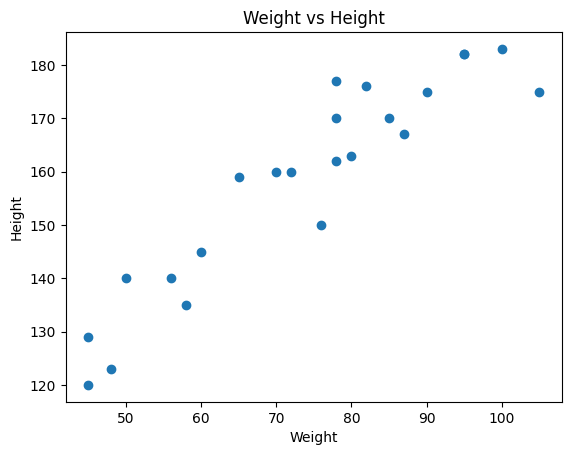

In [43]:
# Scatter plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Weight vs Height')
plt.show()

From this plot we can see that as the weight is increasing height is also increasing. So, this is a kind of Linear Relationship.

If we want to find out whether this relationship is positive or negative. we can see using correlation.

# **Finding Correlation**

In [44]:
# Finding Correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


If we see relationship between weight and height is 0.931142 . That Basically means it is highly positive correlated.

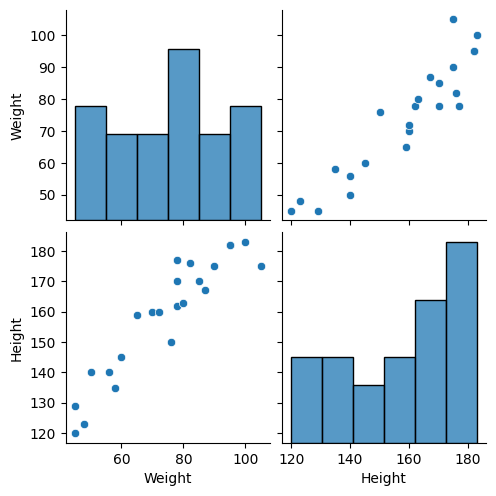

In [45]:
# Seaborn for visualization
import seaborn as sns
sns.pairplot(df)

The same correlation dispalyed using visulization. Height and weight are positively correlated.

If the data shows a **strong linear correlation** between the independent feature (**X**) and the target variable (**Y**), it is a good indication that **Linear Regression is likely to perform well**.

However, having a linear relationship is not the only requirement. Other factors also need to be considered, especially when working with **Multiple Linear Regression**.

In **Simple Linear Regression**, we have only **one independent feature**, so we only need to check the relationship between that feature and the target variable.

In **Multiple Linear Regression**, where there are **two or more independent features**, we must also examine the relationship **among the independent features themselves**.

One common issue is **Multicollinearity**.


**Multicollinearity** occurs when two or more independent features are **highly correlated with each other**. In such cases, these features carry very similar information, making some of them redundant.









To reduce this problem, we can remove one of the highly correlated features and keep the other, since both provide nearly the same information to the model. This helps improve model stability, interpretability, and performance.


# **Independent and Dependent Features**

In [47]:
# Independent and Dependent Features
x = df[['Weight']]
x.head()

y = df['Height']
y.head()

,Height
0,120
1,135
2,123
3,145
4,160


In [48]:
x.head()

,Weight
0,45
1,58
2,48
3,60
4,70


In [49]:
y.head()

,Height
0,120
1,135
2,123
3,145
4,160


 * Independent Feature should be in 2D Array ( or In DataFrame)
 * Dependent Feature can be in series. There is only one feature or one column value

# **Train and Test Split**

In [50]:
# Train and Test Split
from sklearn.model_selection import train_test_split

In [51]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)


**What does `test_size=0.25` mean?**

* `test_size=0.25` means **25% of the data** will be used as the **test dataset**.
* The remaining **75% of the data** will be used as the **training dataset**.

### Example

Suppose your dataset contains **100 records**.

| Dataset      | Percentage | Number of Records |
| ------------ | ---------: | ----------------: |
| Training Set |        75% |                75 |
| Testing Set  |        25% |                25 |

So,

* **75 records** → Train the model.
* **25 records** → Evaluate how well the model performs on unseen data.

---

 **Other Examples**

| `test_size` | Training Data | Testing Data |
| ----------- | ------------: | -----------: |
| `0.2`       |           80% |          20% |
| `0.25`      |           75% |          25% |
| `0.3`       |           70% |          30% |
| `0.4`       |           60% |          40% |

---


> **Rule of thumb:** A `test_size` of **0.2 (20%)** or **0.25 (25%)** is commonly used, though the ideal split depends on the size of your dataset and the problem you're solving.


**Understanding `random_state` in Train-Test Split**

When splitting a dataset into **training** and **testing** sets, there is an important parameter called **`random_state`**.

By default, `train_test_split()` randomly selects the samples for the training and testing datasets.

For example, if we use:

* **75%** of the data for training
* **25%** of the data for testing

the records are selected **randomly** each time the code is executed.

**Why do we use `random_state`?**

If we do **not** specify `random_state`, every execution of the code may produce a **different train-test split**. This means:

* Different records may be selected for the training set.
* Different records may be selected for the testing set.
* As a result, the model's performance may vary slightly every time you run the program.

To make the split **reproducible**, we specify a fixed value for `random_state`, such as:

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)
```

**What does `random_state=42` mean?**

The value **42** is simply a fixed seed used by the random number generator.

Using the same `random_state` ensures that:

* The same training samples are selected every time.
* The same testing samples are selected every time.
* Anyone running the same code with the same dataset and the same `random_state` will obtain an identical train-test split.

> **Note:** The number **42** has no special mathematical significance. It is simply a commonly used convention. Any fixed integer (such as 0, 10, 100, or 123) can be used.





In [52]:
# checking x_train shape
x_train.shape

(17, 1)


**Understanding the Shape of `X_train`**

After performing the train-test split, you can check the dimensions of the training data using:

```python
print(X_train.shape)
```

Suppose the output is:

```python
(17, 1)
```

This means:

* **17** → Number of training samples (rows)
* **1** → Number of input features (columns)

Even if your dataset contains only **one feature**, `X_train` is still stored as a **2-dimensional array**.

### Why is it 2-dimensional?

Machine learning models in Scikit-learn expect the input data (`X`) to always have the shape:

```text
(Number of Samples, Number of Features)
```

For example:

| Number of Samples | Number of Features | Shape       |
| ----------------: | -----------------: | :---------- |
|                17 |                  1 | `(17, 1)`   |
|                17 |                  5 | `(17, 5)`   |
|               100 |                 10 | `(100, 10)` |

So:

* The **first dimension** always represents the number of data points (rows).
* The **second dimension** always represents the number of input features (columns).

Regardless of whether you have **1 feature** or **100 features**, `X_train` will always be a **2-dimensional matrix**.

# **Standardization**

**Feature Standardization (Z-Score Normalization)**

Before training a Linear Regression model, an important preprocessing step is **Feature Standardization**.

Consider a dataset with two independent features:

* **Feature X:** Weight (measured in kilograms)
* **Feature Y:** Height (measured in centimeters)

For example:

| Weight (kg) | Height (cm) |
| ----------- | ----------: |
| 55          |         165 |
| 70          |         175 |
| 82          |         180 |

Notice that these features have **different units and different numerical ranges**.

* Weight values are around **50–100**
* Height values are around **150–200**

Since the scales are different, the feature with the **larger numerical values** can have a greater influence during model training.

---

**Why Does This Matter?**

Many machine learning algorithms, including **Linear Regression (when optimized using Gradient Descent)**, update the model parameters by calculating gradients.

If one feature has much larger values than another:

* The optimization process becomes inefficient.
* Gradient updates can become unbalanced.
* The algorithm may require more iterations to reach the **global minimum**.
* Training can become slower.

Standardization puts all features on a **similar scale**, making optimization faster and more stable.

Standardization transforms each feature using the **Z-Score formula**

---

**What Happens After Standardization?**

After applying the Z-score formula:

* The **mean** of the feature becomes **0**.
* The **standard deviation** becomes **1**.

This does **not** change the relationships between the data points—it only changes their scale.

For example:

| Original Weight (kg) | Standardized Value |
| -------------------: | -----------------: |
|                   55 |              -1.20 |
|                   70 |               0.15 |
|                   82 |               1.05 |

Now all features are on a comparable scale, regardless of their original units.

he values between 0 and 1 are from Min-Max Scaling, not Standardization.

---

**Which Features Should Be Standardized?**

Standardization is applied **only to the independent features (X)**.

The **target variable (y)** is **not** standardized in most Linear Regression problems.

---

> **Important:** Always call `fit()` (or `fit_transform()`) **only on the training data**. The test data should be transformed using the same mean and standard deviation learned from the training set. This prevents **data leakage** and ensures a fair evaluation of the model.


In [53]:
# Standardization
from sklearn.preprocessing import StandardScaler

In [54]:
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)

In [55]:
x_train

array([[ 1.45675115],
       [-0.18252438],
       [-1.47052658],
       [ 1.16402338],
       [ 0.28584006],
       [-0.59234326],
       [-0.29961548],
       [-1.58761768],
       [ 0.16874895],
       [ 0.05165784],
       [ 0.16874895],
       [ 0.87129561],
       [ 0.69565894],
       [-0.88507103],
       [-1.76325435],
       [ 0.16874895],
       [ 1.74947892]])

In [56]:
x_test = scalar.transform(x_test)

In [57]:
x_test

array([[ 1.16402338],
       [ 0.40293117],
       [-1.11925325],
       [ 0.57856783],
       [-1.76325435],
       [-1.00216214]])

**Why Do We Use `fit_transform()` on Training Data and `transform()` on Test Data?**

When performing **feature standardization**, it is very important to use:

* `fit_transform()` on the **training data**
* `transform()` on the **test data**

This is one of the most important preprocessing rules in Machine Learning.

---

**Step 1: Standardize the Training Data**

The standardization formula is:

[
z=\frac{x-\mu}{\sigma}
]

where:

* (x) = Original value
* (\mu) = Mean of the training feature
* (\sigma) = Standard deviation of the training feature

When we execute:

```python
X_train = scaler.fit_transform(X_train)
```

two operations are performed:

1. `fit()`

The scaler **learns** the statistics from the training data.

It calculates:

* Mean ((\mu))
* Standard Deviation ((\sigma))

For example:

```text
Training Data

Weight (kg)

55
60
70
75
80

Mean (μ) = 68
Standard Deviation (σ) = 9.6
```

2. `transform()`

After learning the mean and standard deviation, the scaler applies:

[
z=\frac{x-\mu}{\sigma}
]

to every training sample.

---

**Step 2: Standardize the Test Data**

Now suppose the test data is:

```text
65
72
85
```

Instead of calculating a **new** mean and standard deviation for the test data, we use:

```python
X_test = scaler.transform(X_test)
```

Notice that we **do not** write:

```python
X_test = scaler.fit_transform(X_test)   ❌ Wrong
```

Instead, we write:

```python
X_test = scaler.transform(X_test)       ✅ Correct
```

The scaler uses the **same** values learned from the training data:

* Mean = 68
* Standard Deviation = 9.6

Then it applies:

[
z=\frac{x-68}{9.6}
]

to every test sample.

---

**Why Not Use `fit_transform()` on the Test Data?**

If we use:

```python
scaler.fit_transform(X_test)
```

the scaler will calculate a **new mean** and a **new standard deviation** from the **test data**.

For example:

```text
Test Data

65
72
85

Mean = 74
Standard Deviation = 10
```

Now the test data is standardized using different statistics.

This makes the training data and test data follow **different scaling rules**, which is incorrect.

This mistake leads to a problem called **Data Leakage**.

If we call fit() or fit_transform() on the test data, the scaler calculates the test data's mean and standard deviation. This means the preprocessing step has learned information from the test set, which is called data leakage.


Since the test set is meant to represent **unseen data**, the model should never gain any information from it before evaluation.

If the scaler learns the test data's mean and standard deviation, it indirectly uses information that should remain hidden until testing.

As a result:

* Model evaluation becomes unfair.
* Performance metrics may appear better than they actually are.
* The model may not perform as well on truly unseen data.

---
> **Golden Rule:** **Fit once on the training data, then use the same fitted scaler to transform every future dataset (validation, test, or new prediction data).** This prevents **data leakage** and ensures a fair evaluation of the model.


# **Apply Simple Linear Regression**

`**Initializing the Linear Regression Model**`

After preprocessing the data, the next step is to create a **Linear Regression** model.


Scikit-learn provides several parameters that can be customized when creating the model.

---

**Important Parameters of `LinearRegression`**

1. `fit_intercept` **bold text**

```python
model = LinearRegression(fit_intercept=True)
```

This parameter determines whether the model should calculate the **intercept (bias term)**.

The linear regression equation is:` y = beta0 + beta1*x`


Where:

* (\beta_0) = Intercept (bias)
* (\beta_1) = Coefficient (slope)

If:

```python
fit_intercept=True
```

the model learns both:

* Intercept (beta0))
* Coefficients ((beta_1, beta_2, ...))

If:

```python
fit_intercept=False
```

the model assumes the intercept is **0**, and the regression line must pass through the origin.

In most real-world problems, we keep:

```python
fit_intercept=True
```

which is also the default value.

---

**2. Feature Scaling (`normalize`)**

Older versions of Scikit-learn had a parameter called:

```python
normalize=True
```

However, this parameter has been **deprecated and removed**.

Today, the recommended approach is to standardize the features **before** training the model using:

```python
from sklearn.preprocessing import StandardScaler
```

This is the standard and recommended preprocessing workflow.

---

**3. `n_jobs`**

```python
model = LinearRegression(n_jobs=-1)
```

`n_jobs` controls how many CPU cores are used during computation.

Common values:

| Value | Meaning                     |
| ----- | --------------------------- |
| `1`   | Use one CPU core            |
| `2`   | Use two CPU cores           |
| `-1`  | Use all available CPU cores |

Using:

```python
n_jobs=-1
```

allows Scikit-learn to utilize all available processor cores, which can speed up computation for large datasets.

> **Note:** For small datasets or simple linear regression with one feature, the performance improvement is usually minimal.

---

**4. `positive`**

```python
model = LinearRegression(positive=False)
```

This parameter specifies whether all coefficients must be positive.

If:

```python
positive=True
```

the model restricts every coefficient to be **greater than or equal to zero**.

If:

```python
positive=False
```

the coefficients can be either:

* Positive
* Negative

In most machine learning problems, we leave it as:

```python
positive=False
```

because features can have either a positive or negative relationship with the target variable.

---

`**Training the Model :**`

Once the model is initialized, it is trained using:

```python
model.fit(X_train, y_train)
```

During training, the algorithm learns the best values of:

* Coefficients
* Intercept

that minimize the prediction error.

---

`**Important Attributes After Training**`

After calling `fit()`, several useful attributes become available.

**1. Coefficients (`coef_`)**

```python
model.coef_
```

Returns the learned coefficient (slope) for each feature.

Example:

```python
array([2.45])
```

This means: y = 2.45x + b

If there are multiple features:

```python
array([1.5, -0.8, 3.2])
```

the equation becomes: y = b + 1.5x_1 -0.8x_2 +3.2x_3


Each coefficient represents how much the prediction changes when that feature increases by one unit, while keeping the other features constant.

---

**2. Intercept (`intercept_`)**

```python
model.intercept_
```

Returns the bias (constant term) of the regression equation.

Example:

```python
5.2
```

The final equation becomes: y = 5.2 + 2.45x


---

**3. Feature Names (`feature_names_in_`)**

```python
model.feature_names_in_
```

If the model is trained using a Pandas DataFrame, this attribute returns the names of the input features.

Example:

```python
array(['Age', 'Salary'])
```

This helps identify which coefficient belongs to which feature.

---

**Other Attributes**

Scikit-learn also provides additional attributes such as:

* `rank_` – Rank of the feature matrix.
* `singular_` – Singular values of the feature matrix.

These are mainly useful for numerical analysis and debugging.

For most machine learning tasks, the most important attributes are:

* `coef_`
* `intercept_`
* `feature_names_in_`


In [58]:
from sklearn.linear_model import LinearRegression

In [59]:
regression = LinearRegression(n_jobs= -1)

In [60]:
regression.fit(x_train, y_train)

LinearRegression(n_jobs=-1)

In [64]:
# slope(beta1)  ->  y Hat = beta0 + beta1 * x1(weight)
print("Coefficient or Slope :", regression.coef_ )
print("Intercept :", regression.intercept_ )

Coefficient or Slope : [16.53415595]
Intercept : 159.47058823529412


One unit movement in weight valuethat leads to 16.53 units in height value.

When the weight value is 0 at what point your line is meeting in the y . that point is = 159.47

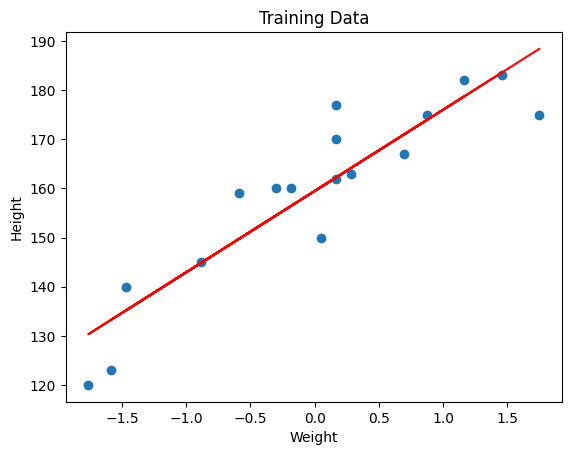

In [67]:
# plot training data - plot best fit line

plt.scatter(x_train, y_train)
plt.plot(x_train, regression.predict(x_train), color='red')
plt.title('Training Data')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

# **Prediction for the test data**

In [ ]:
# Predication of test data

# 1. Predicted height output = intercept + coef_(weight)
# 2. y_pred_test = regression.intercept_ + regression.coef_ * x_test
#                = 159.47058823529412 + 16.53415595 * x_test

In [73]:
# The 'predict' method of the trained regression model takes the independent
# features (x_test) and returns the predicted dependent feature (y_pred)

y_pred = regression.predict(x_test)

In [74]:
y_pred

array([178.71673229, 166.13271502, 140.96468049, 169.03671901,
       130.31666588, 142.90068314])

# **Performance Metrics**

In [75]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [76]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)

Mean Squared Error (MSE): 29.02601358548199
Root Mean Squared Error (RMSE): 5.387579566510548
Mean Absolute Error (MAE): 4.049310530227544


In [78]:
# R-squared
from sklearn.metrics import r2_score

In [80]:
score = r2_score(y_test, y_pred)
print("R-squared:", score)

R-squared: 0.935386069188885


In [81]:
# Adjusted R-squared

# n represents the number of observations (samples) in the test set.
n = x_test.shape[0]
# p represents the number of independent variables (features) in the test set.
p = x_test.shape[1]
adjusted_r2 = 1 - (1 - score) * ((n - 1) / (n - p - 1))
print("Adjusted R-squared:", adjusted_r2)

Adjusted R-squared: 0.9192325864861063


# **OLS Linear Regression**

In [82]:
import statsmodels.api as sm

In [83]:
model = sm.OLS(y_train, x_train).fit()

In [85]:
predictions = model.predict(x_test)

In [86]:
predictions

array([ 19.24614406,   6.66212679, -18.50590775,   9.56613077,
       -29.15392236, -16.56990509])

In [87]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.011
Model:                            OLS   Adj. R-squared (uncentered):             -0.051
Method:                 Least Squares   F-statistic:                             0.1716
Date:                Fri, 03 Jul 2026   Prob (F-statistic):                       0.684
Time:                        09:08:29   Log-Likelihood:                         -110.36
No. Observations:                  17   AIC:                                      222.7
Df Residuals:                      16   BIC:                                      223.6
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

# **Prediction for new Data**

In [90]:
# for 72 weight height will be 156.45
regression.predict(scalar.transform([[72]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([156.45270174])

New data points must be in 2D like [[72 weight]] , and also we need to do standardization of new data points , otherwise it will not gave correct value or output.

In [91]:
# Without  standardization
regression.predict([[72]])


array([1349.92981637])